<a href="https://colab.research.google.com/github/akhilesh2009/housing_prices_competition/blob/main/housing_prices_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Housing Prices Competition for Kaggle Learn Users**

**Importing required Libraries**

In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

**saving the train dataset in a variable called train**

In [305]:
train = pd.read_csv("/content/drive/MyDrive/train.csv")
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [306]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Plotting a graph relation b/w LotArea & SalePrice**

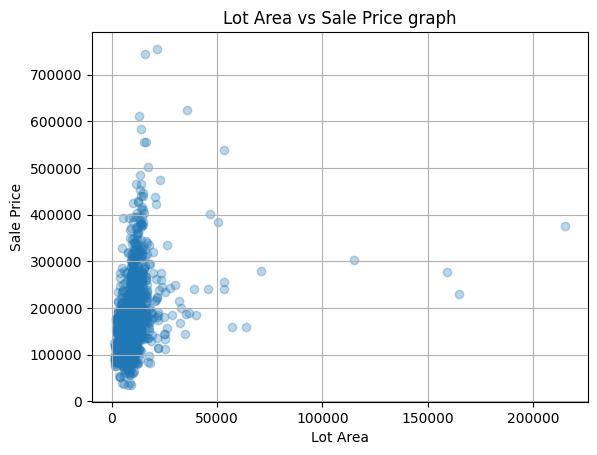

In [307]:
def area_price_graph():
  lot_area = train["LotArea"]
  sale_price = train["SalePrice"]
  plt.scatter(lot_area, sale_price, alpha=0.3)
  plt.title("Lot Area vs Sale Price graph")
  plt.xlabel("Lot Area")
  plt.ylabel("Sale Price")
  plt.grid(True)
  plt.show

area_price_graph()

**Dropping useless columns**

In [308]:
train = train.drop(["LandContour", "LotConfig", "LandSlope", "Condition1", "Condition2",
                    "Exterior1st", "Exterior2nd", "MasVnrType", "MasVnrArea", "BsmtExposure",
                    "BsmtFinType2","BsmtFinSF1", "BsmtUnfSF", "HeatingQC", "Electrical",
                    "LowQualFinSF", "GrLivArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
                    "3SsnPorch", "MiscFeature", "PoolQC", "Fence", "FireplaceQu", "Alley"], axis="columns")

**Dataset after removing useless columns**

In [309]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,Utilities,Neighborhood,BldgType,...,GarageCond,PavedDrive,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,AllPub,CollgCr,1Fam,...,TA,Y,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,AllPub,Veenker,1Fam,...,TA,Y,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,AllPub,CollgCr,1Fam,...,TA,Y,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,AllPub,Crawfor,1Fam,...,TA,Y,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,AllPub,NoRidge,1Fam,...,TA,Y,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,AllPub,Gilbert,1Fam,...,TA,Y,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,AllPub,NWAmes,1Fam,...,TA,Y,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,AllPub,Crawfor,1Fam,...,TA,Y,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,AllPub,NAmes,1Fam,...,TA,Y,0,0,0,4,2010,WD,Normal,142125


**Checking data type of each object in the dataset**

In [310]:
train.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
LotShape,object
Utilities,object
Neighborhood,object
BldgType,object


**Checking for NaN values**

In [311]:
train.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
LotShape,0
Utilities,0
Neighborhood,0
BldgType,0


**Filling up NaN values**

In [312]:
train["LotFrontage"] = train["LotFrontage"].fillna(train.groupby("LotArea")["SalePrice"].transform("median"))
train["GarageYrBlt"] = train["GarageYrBlt"].fillna(train["GarageYrBlt"].median())
train["BsmtQual"] = train["BsmtQual"].fillna("Na")
train["BsmtCond"] = train["BsmtCond"].fillna("Na")
train["BsmtFinType1"] = train["BsmtFinType1"].fillna("Na")
train["GarageCond"] = train["GarageCond"].fillna("Na")
train["GarageQual"] = train["GarageQual"].fillna("Na")
train["GarageFinish"] = train["GarageFinish"].fillna("Na")
train["GarageYrBlt"] = train["GarageYrBlt"].fillna("Na")
train["GarageType"] = train["GarageType"].fillna("Na")

**Converting categorical values to numerical**

In [313]:
ordinal_encoder = OrdinalEncoder()
cols_to_encode = ["MSZoning", "Street", "LotShape", "Utilities", "Neighborhood", "BldgType",
                  "HouseStyle", "RoofStyle", "RoofMatl", "ExterQual", "ExterCond", "Foundation",
                  "BsmtQual", "BsmtCond", "BsmtFinType1", "Heating", "CentralAir", "KitchenQual",
                  "Functional", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PavedDrive",
                  "SaleType", "SaleCondition"]
train_processed = train.copy()
train_processed[cols_to_encode] = ordinal_encoder.fit_transform(train_processed[cols_to_encode])
train_encoded = train_processed
train_encoded

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,Utilities,Neighborhood,BldgType,...,GarageCond,PavedDrive,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3.0,65.0,8450,1.0,3.0,0.0,5.0,0.0,...,5.0,2.0,0,0,0,2,2008,8.0,4.0,208500
1,2,20,3.0,80.0,9600,1.0,3.0,0.0,24.0,0.0,...,5.0,2.0,0,0,0,5,2007,8.0,4.0,181500
2,3,60,3.0,68.0,11250,1.0,0.0,0.0,5.0,0.0,...,5.0,2.0,0,0,0,9,2008,8.0,4.0,223500
3,4,70,3.0,60.0,9550,1.0,0.0,0.0,6.0,0.0,...,5.0,2.0,0,0,0,2,2006,8.0,0.0,140000
4,5,60,3.0,84.0,14260,1.0,0.0,0.0,15.0,0.0,...,5.0,2.0,0,0,0,12,2008,8.0,4.0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3.0,62.0,7917,1.0,3.0,0.0,8.0,0.0,...,5.0,2.0,0,0,0,8,2007,8.0,4.0,175000
1456,1457,20,3.0,85.0,13175,1.0,3.0,0.0,14.0,0.0,...,5.0,2.0,0,0,0,2,2010,8.0,4.0,210000
1457,1458,70,3.0,66.0,9042,1.0,3.0,0.0,6.0,0.0,...,5.0,2.0,0,0,2500,5,2010,8.0,4.0,266500
1458,1459,20,3.0,68.0,9717,1.0,3.0,0.0,12.0,0.0,...,5.0,2.0,0,0,0,4,2010,8.0,4.0,142125


**Creating X and y**

In [314]:
X = train_encoded.drop("SalePrice", axis="columns")
y = train_encoded["SalePrice"]

**Spliting train test data**

In [315]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Using Ridge Regression Model**

In [316]:
ridge_reg = Ridge(alpha=0.1, solver="auto", random_state=42)
ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)

**Measuring Performance using RMSE**

In [317]:
lin_rmse = root_mean_squared_error(y_test, y_pred)
lin_rmse

34288.62205665931

# **Using LinrearSVR model**

In [318]:
lin_svr = LinearSVR(random_state=42, C=100)
lin_svr.fit(X_train, y_train)
y_pred = lin_svr.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


**Measuring Performance using RMSE**

In [319]:
lin_rmse = root_mean_squared_error(y_test, y_pred)
lin_rmse

52785.585673140755

# **Using RandomForestRegression Model**

In [320]:
rndf_reg = RandomForestRegressor(random_state=42)
rndf_reg.fit(X_train, y_train)
y_pred = rndf_reg.predict(X_test)

**Measuring Performance using RMSE**

In [321]:
lin_rmse = root_mean_squared_error(y_test, y_pred)
lin_rmse

29403.190479713572

# **Predicting on Test Set**

In [322]:
test = pd.read_csv("/content/drive/MyDrive/test.csv")
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


**Dropping useless columns**

In [323]:
test = test.drop(["LandContour", "LotConfig", "LandSlope", "Condition1", "Condition2",
                    "Exterior1st", "Exterior2nd", "MasVnrType", "MasVnrArea", "BsmtExposure",
                    "BsmtFinType2","BsmtFinSF1", "BsmtUnfSF", "HeatingQC", "Electrical",
                    "LowQualFinSF", "GrLivArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
                    "3SsnPorch", "MiscFeature", "PoolQC", "Fence", "FireplaceQu", "Alley"], axis="columns")

**Encoding Categorical Values**

In [324]:
cols_to_encode = ["MSZoning", "Street", "LotShape", "Utilities", "Neighborhood", "BldgType",
                  "HouseStyle", "RoofStyle", "RoofMatl", "ExterQual", "ExterCond", "Foundation",
                  "BsmtQual", "BsmtCond", "BsmtFinType1", "Heating", "CentralAir", "KitchenQual",
                  "Functional", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PavedDrive",
                  "SaleType", "SaleCondition"]
test_processed = test.copy()
test_processed[cols_to_encode] = ordinal_encoder.fit_transform(test_processed[cols_to_encode])
test_encoded = test_processed
test_encoded

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,Utilities,Neighborhood,BldgType,...,GarageQual,GarageCond,PavedDrive,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,2.0,80.0,11622,1.0,3.0,0.0,12.0,0.0,...,3.0,4.0,2.0,120,0,0,6,2010,8.0,4.0
1,1462,20,3.0,81.0,14267,1.0,0.0,0.0,12.0,0.0,...,3.0,4.0,2.0,0,0,12500,6,2010,8.0,4.0
2,1463,60,3.0,74.0,13830,1.0,0.0,0.0,8.0,0.0,...,3.0,4.0,2.0,0,0,0,3,2010,8.0,4.0
3,1464,60,3.0,78.0,9978,1.0,0.0,0.0,8.0,0.0,...,3.0,4.0,2.0,0,0,0,6,2010,8.0,4.0
4,1465,120,3.0,43.0,5005,1.0,0.0,0.0,22.0,4.0,...,3.0,4.0,2.0,144,0,0,1,2010,8.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,4.0,21.0,1936,1.0,3.0,0.0,10.0,3.0,...,NaN,NaN,2.0,0,0,0,6,2006,8.0,4.0
1455,2916,160,4.0,21.0,1894,1.0,3.0,0.0,10.0,4.0,...,3.0,4.0,2.0,0,0,0,4,2006,8.0,0.0
1456,2917,20,3.0,160.0,20000,1.0,3.0,0.0,11.0,0.0,...,3.0,4.0,2.0,0,0,0,9,2006,8.0,0.0
1457,2918,85,3.0,62.0,10441,1.0,3.0,0.0,11.0,0.0,...,NaN,NaN,2.0,0,0,700,7,2006,8.0,4.0


**Predicting on test set using rndf_reg**

In [325]:
test_pred = rndf_reg.predict(test_encoded)

**Creating the submission.csv**

In [327]:

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_pred
})

submission.to_csv("submission.csv", index=False)

In [328]:
pd.read_csv("submission.csv")

,Id,SalePrice
0,1461,122732.25
1,1462,157567.86
2,1463,162639.00
3,1464,180001.96
4,1465,214612.75
...,...,...
1454,2915,90490.50
1455,2916,86496.50
1456,2917,159027.37
1457,2918,121119.39
